# Evaluation — llama3.3:70b (Ollama)

## Experiment metadata

| | Batch | Whole-doc |
|---|---|---|
| **Prompt strategy** | 10 blocks/request · 3-block sliding context window | All blocks in 1 request · model sees full document |
| **Input files** | `data/output/labeled/llama3.3-70b_batch/sampleN.json` | `data/output/labeled/llama3.3-70b_whole_doc/sampleN.json` |
| **Regenerate** | `dmpbridge-experiment experiments/llama3.3-70b-batch.yaml` | `dmpbridge-wholedoc --provider ollama --model llama3.3:70b` |
| **Provider** | Ollama (local) | Ollama (local) |
| **Model size** | 70B parameters, Q4_K_M quantisation | same |

**Labels (5):** `title` · `section.title` · `section.description` · `question.text` · `answer.text`  
**Evaluation:** block-level accuracy + F1 against `data/input/ground_truth/sampleN_dmp.json`  — no new files are written.

---

## Sections
1. Accuracy summary — per-sample table and batch vs whole-doc delta
2. Per-sample accuracy — side-by-side bar chart
3. Confusion matrix — raw counts and row-normalised recall
4. Precision / Recall / F1 — per label with batch vs whole-doc comparison
5. Mislabeled blocks — error breakdown and full detail table

In [1]:
MODEL_NAME    = "llama3.3-70b"
MODEL_DISPLAY = "llama3.3:70b"
COLOR_BATCH   = "#1d4ed8"   # dark blue
COLOR_WHOLE   = "#60a5fa"   # medium blue
CMAP_BATCH    = "Blues"
CMAP_WHOLE    = "YlGnBu"

In [2]:
from dmpbridge.evaluation.evaluate import (
    extract_gold, evaluate_sample, match,
    LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH,
    load_method, compute_f1_rows,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",    "grid.linewidth":0.5,
    "text.color":"#111111",    "axes.labelcolor":"#111111",
    "xtick.color":"#111111",   "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True,
    "figure.dpi":120,
})

# File tags: sampleN_{tag}.json  —  batch uses _batch suffix, whole-doc uses _whole_doc suffix
df_b, conf_b, errs_b = load_method(f"{MODEL_NAME}_batch")
df_w, conf_w, errs_w = load_method(f"{MODEL_NAME}_whole_doc")

WHOLEDOC_AVAILABLE = df_w is not None and not df_w.empty

tc_b, tn_b = int(df_b["correct"].sum()), int(df_b["total"].sum())
print(f"Batch     ({MODEL_NAME}_batch)     : {tc_b}/{tn_b} ({tc_b/tn_b*100:.1f}%)")
if WHOLEDOC_AVAILABLE:
    tc_w, tn_w = int(df_w["correct"].sum()), int(df_w["total"].sum())
    print(f"Whole-doc ({MODEL_NAME}_whole_doc) : {tc_w}/{tn_w} ({tc_w/tn_w*100:.1f}%)")
else:
    print(f"Whole-doc : not available — run: dmpbridge-wholedoc --provider ollama --model {MODEL_DISPLAY}")

Batch     (llama3.3-70b_batch)     : 695/741 (93.8%)
Whole-doc (llama3.3-70b_whole_doc) : 680/741 (91.8%)


## 1 — Accuracy summary

- **Accuracy** = blocks where the predicted label exactly matches gold.
- **Delta** = whole-doc minus batched. Positive = whole-doc is better on that sample.
- A single bad sample can pull the overall number down significantly — check the per-sample view next.

In [3]:
def print_table(df, label):
    hdr = f"{'Sample':<12}  {'Total':>5}  {'Correct':>7}  {'Errors':>6}  {'Accuracy':>8}  Formula"
    print(f"  {label}")
    print("  " + "-" * len(hdr))
    for row in df.itertuples():
        print(f"  {row.sample:<12}  {row.total:>5}  {row.correct:>7}  "
              f"{row.errors:>6}  {row.accuracy*100:>7.1f}%  {row.formula}")
    print("  " + "-" * len(hdr))
    tn, tc = df["total"].sum(), df["correct"].sum()
    print(f"  {'TOTAL':<12}  {tn:>5}  {tc:>7}  {tn-tc:>6}  {tc/tn*100:>7.1f}%  {tc}/{tn}\n")

print_table(df_b, f"Batched — {MODEL_NAME}")

if WHOLEDOC_AVAILABLE:
    print_table(df_w, f"Whole-doc — {MODEL_NAME}")
    merged = df_b[["sample","accuracy"]].rename(columns={"accuracy":"batch"}).merge(
             df_w[["sample","accuracy"]].rename(columns={"accuracy":"whole"}), on="sample")
    merged["delta"] = merged["whole"] - merged["batch"]
    print(f"  {'Sample':<12}  {'Batched':>9}  {'Whole-doc':>10}  {'Delta':>8}")
    print("  " + "-" * 46)
    for _, r in merged.iterrows():
        sign = '+' if r['delta'] >= 0 else ''
        print(f"  {r['sample']:<12}  {r['batch']*100:>8.1f}%  {r['whole']*100:>9.1f}%  {sign}{r['delta']*100:>6.1f}%")
    tb = df_b['correct'].sum() / df_b['total'].sum()
    tw = df_w['correct'].sum() / df_w['total'].sum()
    sign = '+' if (tw - tb) >= 0 else ''
    print("  " + "-" * 46)
    print(f"  {'OVERALL':<12}  {tb*100:>8.1f}%  {tw*100:>9.1f}%  {sign}{(tw-tb)*100:>6.1f}%")

  Batched — llama3.3-70b
  -------------------------------------------------------
  sample1          78       76       2     97.4%  76/78
  sample2         172      156      16     90.7%  156/172
  sample3          69       68       1     98.6%  68/69
  sample4          78       78       0    100.0%  78/78
  sample5          86       77       9     89.5%  77/86
  sample6          29       18      11     62.1%  18/29
  sample7          17       16       1     94.1%  16/17
  sample8          59       57       2     96.6%  57/59
  sample9          85       84       1     98.8%  84/85
  sample10         68       65       3     95.6%  65/68
  -------------------------------------------------------
  TOTAL           741      695      46     93.8%  695/741

  Whole-doc — llama3.3-70b
  -------------------------------------------------------
  sample1          78       77       1     98.7%  77/78
  sample2         172      136      36     79.1%  136/172
  sample3          69       69       0 

## 2 — Per-sample accuracy

Hatched bars = whole-doc variant.  
Large gaps between the two methods on the same sample = documents where batching loses structural context.

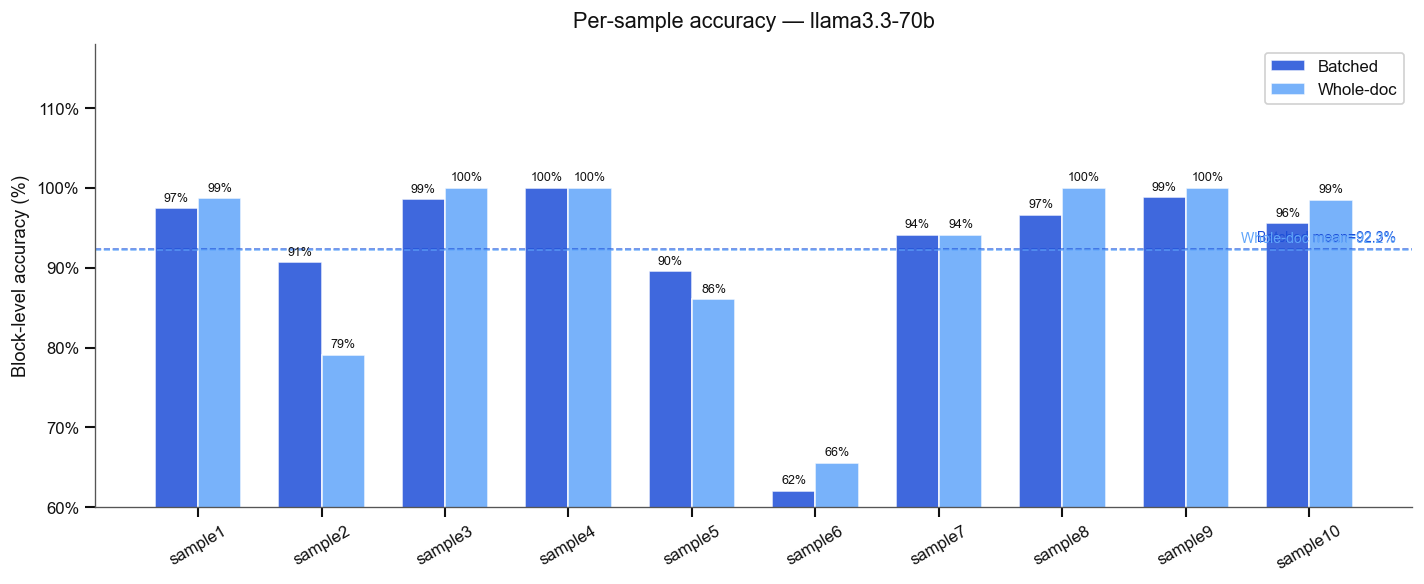

In [4]:
samples_ordered = df_b["sample"].tolist()
x = range(len(samples_ordered))

if WHOLEDOC_AVAILABLE:
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    acc_b = df_b.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    acc_w = df_w.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    bars_b = ax.bar([xi - w/2 for xi in x], acc_b, width=w,
                    label="Batched", color=COLOR_BATCH, alpha=0.85, edgecolor="white")
    bars_w = ax.bar([xi + w/2 for xi in x], acc_w, width=w,
                    label="Whole-doc", color=COLOR_WHOLE, alpha=0.85, edgecolor="white")
    for bar, v in list(zip(bars_b, acc_b)) + list(zip(bars_w, acc_w)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5)
    avg_b, avg_w = acc_b.mean(), acc_w.mean()
    ax.axhline(avg_b, color=COLOR_BATCH, linestyle="--", linewidth=1.0, alpha=0.7)
    ax.axhline(avg_w, color=COLOR_WHOLE, linestyle="--", linewidth=1.0, alpha=0.7)
    ax.text(len(x)-0.3, avg_b+0.6, f"Batched mean={avg_b:.1f}%",
            ha="right", va="bottom", fontsize=8.5, color=COLOR_BATCH)
    ax.text(len(x)-0.3, avg_w+0.6, f"Whole-doc mean={avg_w:.1f}%",
            ha="right", va="bottom", fontsize=8.5, color=COLOR_WHOLE)
    ax.legend(framealpha=0.9)
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    acc_b = df_b.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    colors = [COLOR_BATCH if v >= 95 else "#f59e0b" if v >= 85 else "#dc2626" for v in acc_b]
    bars = ax.bar(samples_ordered, acc_b, color=colors, width=0.6, edgecolor="white")
    for bar, v in zip(bars, acc_b):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    avg_b = acc_b.mean()
    ax.axhline(avg_b, color="#444", linestyle="--", linewidth=1.0)
    ax.text(len(x)-0.45, avg_b+0.7, f"Mean={avg_b:.1f}%",
            ha="right", va="bottom", fontsize=9.5, color="#444")

ax.set_xticks(list(x)); ax.set_xticklabels(samples_ordered, rotation=30)
ax.set_ylim(60, 118); ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(f"Per-sample accuracy — {MODEL_NAME}", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine(); plt.tight_layout(); plt.show()

## 3 — Confusion matrix

Read **row by row**: each row = a true label, each column = what the model predicted.  
A perfect model has all mass on the diagonal.  
The most common failure mode is  being confused with  — both appear in the middle of a section and look like funder instructions.

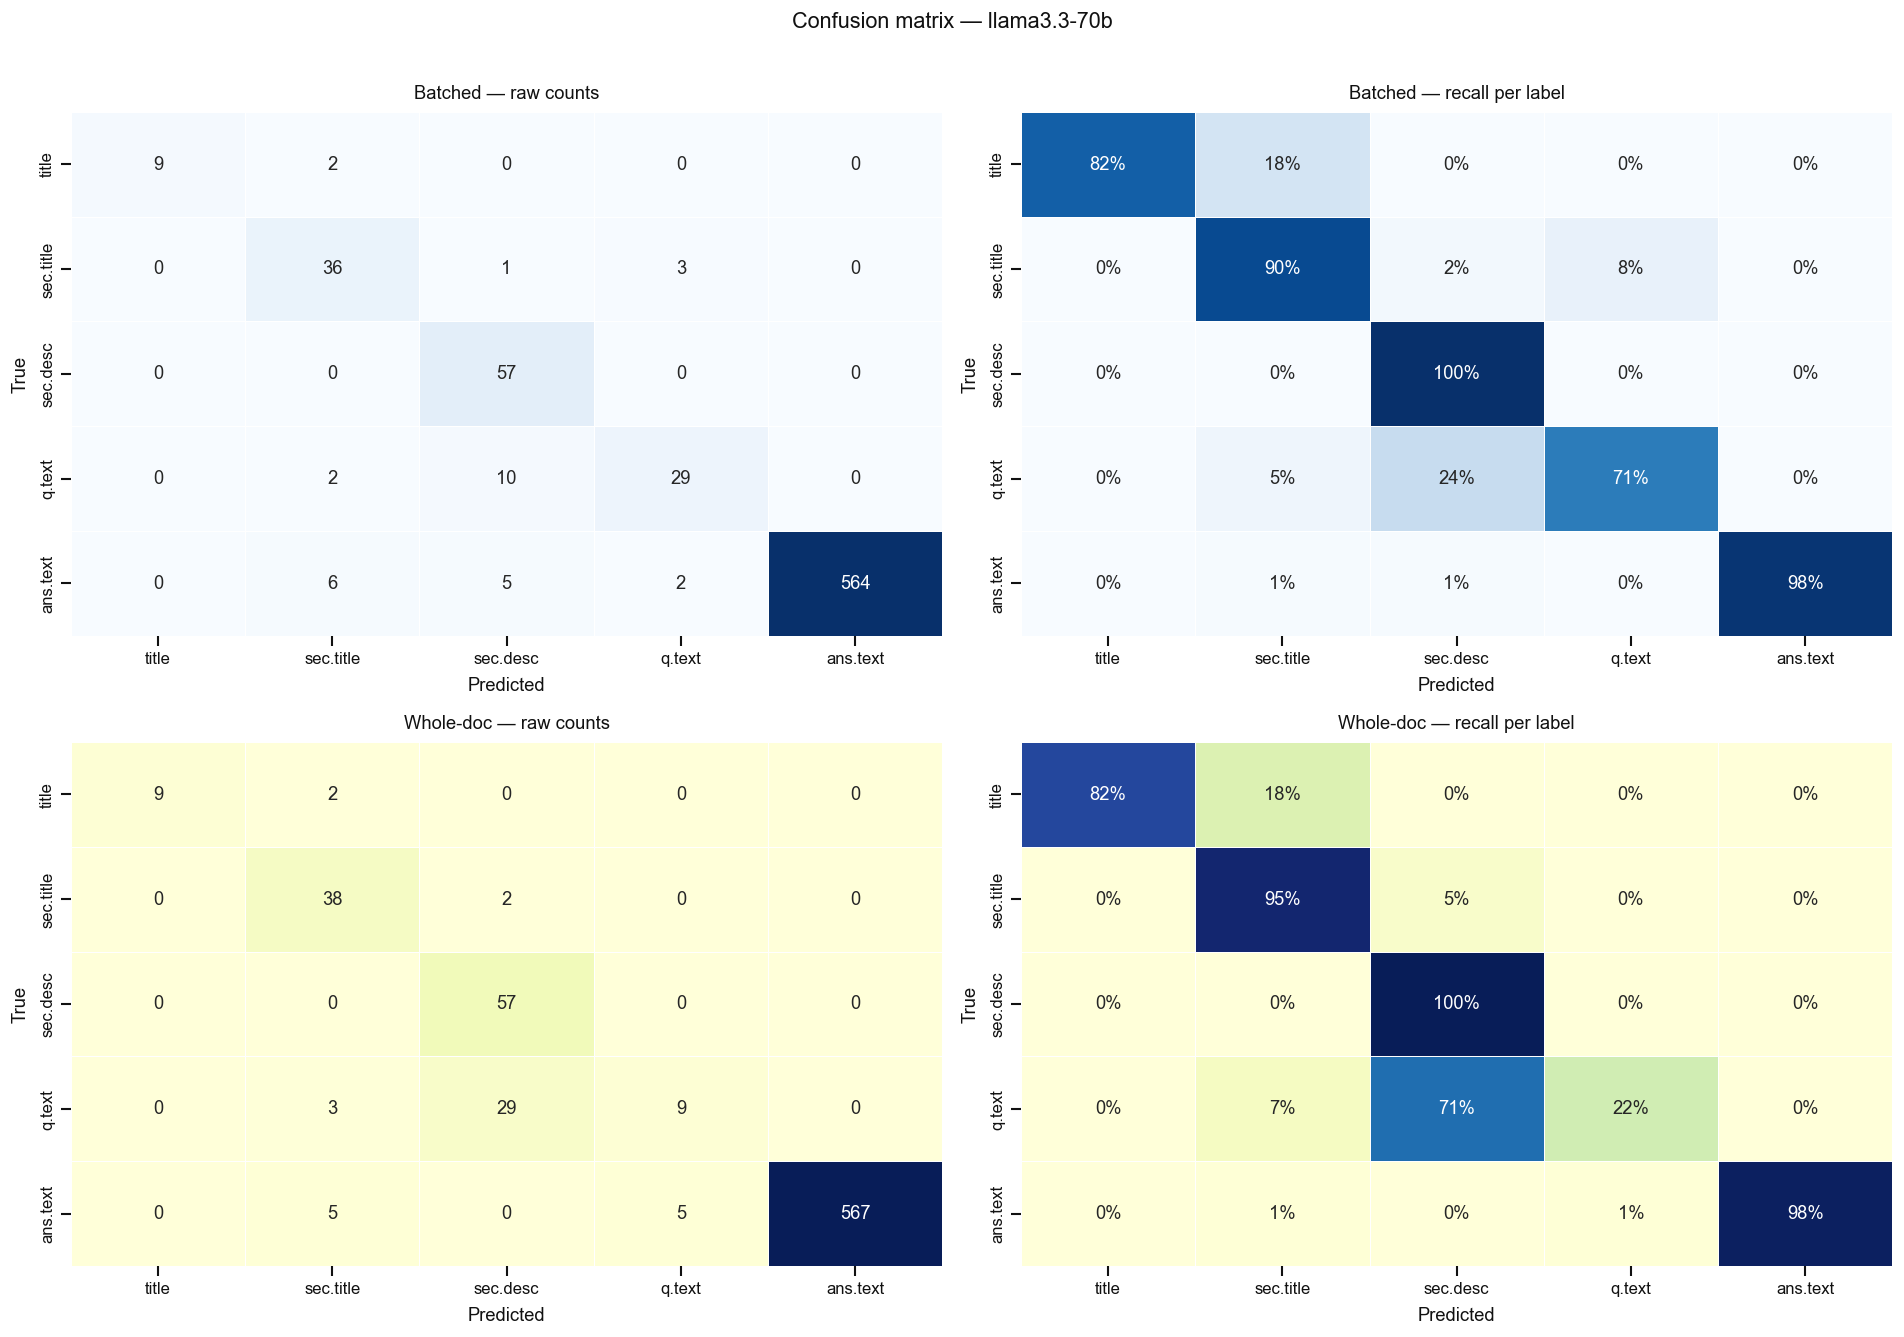

In [5]:
def conf_to_df(conf):
    m = pd.DataFrame(
        [[conf.get(t, {}).get(p, 0) for p in LABELS] for t in LABELS],
        index=SHORT, columns=SHORT)
    return m, m.div(m.sum(axis=1).replace(0, 1), axis=0)

mat_b, mat_bn = conf_to_df(conf_b)

if WHOLEDOC_AVAILABLE:
    mat_w, mat_wn = conf_to_df(conf_w)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    panels = [
        (axes[0,0], mat_b,  "d",   CMAP_BATCH, "Batched — raw counts"),
        (axes[0,1], mat_bn, ".0%", CMAP_BATCH, "Batched — recall per label"),
        (axes[1,0], mat_w,  "d",   CMAP_WHOLE, "Whole-doc — raw counts"),
        (axes[1,1], mat_wn, ".0%", CMAP_WHOLE, "Whole-doc — recall per label"),
    ]
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    panels = [
        (axes[0], mat_b,  "d",   CMAP_BATCH, "Raw counts"),
        (axes[1], mat_bn, ".0%", CMAP_BATCH, "Recall per label (row-normalised)"),
    ]

for ax, mat, fmt, cmap, title in panels:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, linewidths=0.6,
                linecolor="white", ax=ax, cbar=False, annot_kws={"size": 11},
                vmin=(0 if fmt == ".0%" else None), vmax=(1 if fmt == ".0%" else None))
    ax.set_title(title, pad=8, fontsize=11)
    ax.set_xlabel("Predicted", labelpad=6)
    ax.set_ylabel("True", labelpad=6)

plt.suptitle(f"Confusion matrix — {MODEL_NAME}", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 4 — Precision / Recall / F1 per label

F1 balances precision and recall. Values below 80% on a label indicate a reliability risk for the pipeline.  
The delta table at the bottom shows per-label gain from whole-doc context — this is the clearest signal for deciding which strategy to use in production.

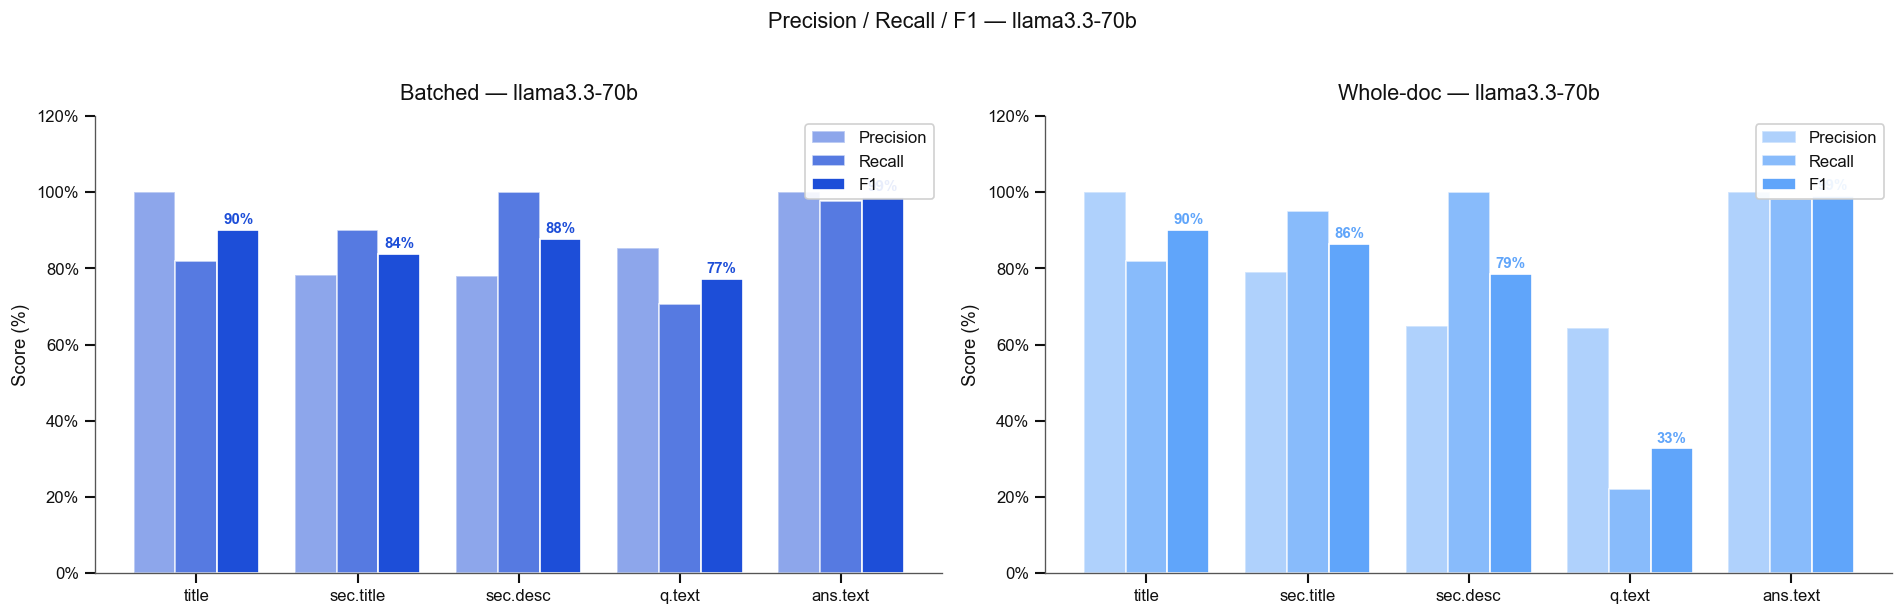

,f1_batch,f1_whole,delta
label,,,
title,90.0%,90.0%,0.0%
section.title,83.7%,86.4%,2.6%
section.description,87.7%,78.6%,-9.1%
question.text,77.3%,32.7%,-44.6%
answer.text,98.9%,99.1%,0.3%


In [6]:
df_f1_b = compute_f1_rows(conf_b)

if WHOLEDOC_AVAILABLE:
    df_f1_w = compute_f1_rows(conf_w)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    panels = [(axes[0], df_f1_b, COLOR_BATCH, f"Batched — {MODEL_NAME}"),
              (axes[1], df_f1_w, COLOR_WHOLE, f"Whole-doc — {MODEL_NAME}")]
else:
    fig, axes = plt.subplots(1, 1, figsize=(10, 5))
    panels = [(axes, df_f1_b, COLOR_BATCH, f"Batched — {MODEL_NAME}")]

for ax, df_f1, color, title in panels:
    xi, w = range(len(LABELS)), 0.26
    ax.bar([i - w for i in xi], df_f1["precision"]*100, width=w, label="Precision",
           color=color, alpha=0.5, edgecolor="white")
    ax.bar([i     for i in xi], df_f1["recall"]*100,    width=w, label="Recall",
           color=color, alpha=0.75, edgecolor="white")
    bars = ax.bar([i + w for i in xi], df_f1["f1"]*100, width=w, label="F1",
                  color=color, edgecolor="white")
    for bar, row in zip(bars, df_f1.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f"{row.f1*100:.0f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=color)
    ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
    ax.set_ylim(0, 120); ax.set_ylabel("Score (%)")
    ax.set_title(title, pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(loc="upper right", framealpha=0.9)
    sns.despine(ax=ax)

plt.suptitle(f"Precision / Recall / F1 — {MODEL_NAME}", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

if WHOLEDOC_AVAILABLE:
    comb = df_f1_b.set_index("label")[["f1"]].rename(columns={"f1":"f1_batch"}).join(
           df_f1_w.set_index("label")[["f1"]].rename(columns={"f1":"f1_whole"}))
    comb["delta"] = comb["f1_whole"] - comb["f1_batch"]
    display(comb.style.format("{:.1%}").background_gradient(subset=["f1_batch","f1_whole"], cmap="Blues"))

## 5 — Mislabeled blocks

Use this table to distinguish **systematic** errors (same true→pred pair, many blocks) from **isolated** ones.  
Systematic patterns → prompt or strategy needs fixing. Isolated → acceptable noise.

In [7]:
def error_breakdown(df_err, label):
    print(f"  {label}: {len(df_err)} mislabeled blocks")
    if df_err.empty:
        print("  No errors.\n"); return
    bd = (df_err.groupby(["true","pred"]).size()
          .reset_index(name="count").sort_values("count", ascending=False))
    print(bd.to_string(index=False)); print()

error_breakdown(errs_b, f"Batched — {MODEL_NAME}")
if WHOLEDOC_AVAILABLE:
    error_breakdown(errs_w, f"Whole-doc — {MODEL_NAME}")

  Batched — llama3.3-70b: 34 mislabeled blocks
         true                pred  count
question.text section.description     10
  answer.text       section.title      6
  answer.text section.description      5
section.title       question.text      3
     no_match       section.title      3
  answer.text       question.text      2
question.text       section.title      2
        title       section.title      2
section.title section.description      1

  Whole-doc — llama3.3-70b: 49 mislabeled blocks
         true                pred  count
question.text section.description     29
  answer.text       section.title      5
  answer.text       question.text      5
     no_match       section.title      3
question.text       section.title      3
section.title section.description      2
        title       section.title      2



In [8]:
pd.set_option("display.max_colwidth", 100)
if not errs_b.empty:
    print("=== Batched errors ===")
    display(errs_b[["sample","page","true","pred","text"]])
if WHOLEDOC_AVAILABLE and not errs_w.empty:
    print("\n=== Whole-doc errors ===")
    display(errs_w[["sample","page","true","pred","text"]])

=== Batched errors ===


,sample,page,true,pred,text
0,sample1,1,answer.text,question.text,The following data will be created as a result of this project:
1,sample1,2,question.text,section.title,"Protections for privacy, rights, and confidentiality of human research participants:"
2,sample2,1,question.text,section.description,the course of the proposed research and which of these are considered Digital Research Data
3,sample2,1,question.text,section.description,necessary to Validate the research findings.
4,sample2,1,question.text,section.description,"applicable, a description of documentation plans, annotation of relevant software, and the ratio..."
5,sample2,1,question.text,section.description,"the selection of appropriate standards. (Existing, accepted community standards should be used w..."
6,sample2,1,question.text,section.description,"possible. Where community standards are missing or inadequate, the DMP could propose alternate"
7,sample2,1,question.text,section.description,"strategies that facilitate data sharing, and should advise the sponsoring program of any need to"
8,sample2,1,question.text,section.description,develop or generalize standards.)
9,sample2,2,question.text,section.title,Data Sharing and Data Preservation. A description of the plans for data sharing and preservation.



=== Whole-doc errors ===


,sample,page,true,pred,text
0,sample1,2,question.text,section.title,"Protections for privacy, rights, and confidentiality of human research participants:"
1,sample2,1,question.text,section.description,the course of the proposed research and which of these are considered Digital Research Data
2,sample2,1,question.text,section.description,necessary to Validate the research findings.
3,sample2,1,question.text,section.description,"Content and Format. A statement of plans for data and metadata content and format including, where"
4,sample2,1,question.text,section.description,"applicable, a description of documentation plans, annotation of relevant software, and the ratio..."
5,sample2,1,question.text,section.description,"the selection of appropriate standards. (Existing, accepted community standards should be used w..."
6,sample2,1,question.text,section.description,"possible. Where community standards are missing or inadequate, the DMP could propose alternate"
7,sample2,1,question.text,section.description,"strategies that facilitate data sharing, and should advise the sponsoring program of any need to"
8,sample2,1,question.text,section.description,develop or generalize standards.)
9,sample2,2,question.text,section.title,Data Sharing and Data Preservation. A description of the plans for data sharing and preservation.
